In [ ]:
# ruff: noqa: T201, RUF001, RUF002, RUF003, E402
# Justification for rule suppressions:
# - T201 (print found): Standard print statements are intentionally utilized for inline
#   execution logging. Standard logging modules would introduce unnecessary verbosity,
#   thereby reducing the readability of the notebook's experimental flow.
# - RUF001 / RUF002 / RUF003 (Ambiguous characters): The inclusion of specific typographic
#   symbols (such as mathematical multiplication or minus signs) is intentional to maintain
#   standard notation and ensure formal clarity within text cells and documentation strings.
# - E402 (Import not at top): In an interactive notebook environment, contextualizing
#   imports within specific cells ensures logical modularity and encapsulation. This prevents
#   unnecessary global scope clutter and allows for isolated cell execution during
#   iterative experimentation without re-running the initial setup.

In [ ]:
# ── Setup & Imports ──────────────────────────────────────────────────
from __future__ import annotations

import math
import warnings
from typing import TYPE_CHECKING, Any

import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

from shapiq import KernelSHAP
from shapiq.approximator import LeverageSHAP
from shapiq.approximator.sampling import CoalitionSampler

if TYPE_CHECKING:
    from shapiq import InteractionValues

warnings.filterwarnings("ignore")


def norm_l2(exact: np.ndarray, approx: np.ndarray) -> float:
    """Normalized ℓ₂ error: ‖exact − approx‖₂ / ‖exact‖₂."""
    denom = np.linalg.norm(exact)
    return 0.0 if denom < 1e-12 else float(np.linalg.norm(exact - approx) / denom)


def extract_sv(iv: InteractionValues, n: int) -> np.ndarray:
    """Extract Shapley vector of length n from an IV mapping."""
    return np.array([iv[(i,)] for i in range(n)])

In [ ]:
class LeverageSHAPWoBernoulli(LeverageSHAP):
    """LeverageSHAP using the standard CoalitionSampler instead of Algorithm 2."""

    def __init__(
        self, n: int, *, pairing_trick: bool = True, random_state: int | None = None, **kwargs: Any
    ) -> None:
        """Initialize the class override for benchmarking."""
        self._explicit_seed = random_state
        super().__init__(n=n, pairing_trick=pairing_trick, random_state=random_state, **kwargs)

    def _sample(self, budget: int) -> tuple[np.ndarray, np.ndarray]:
        sampler = CoalitionSampler(
            n_players=self.n,
            sampling_weights=np.ones(self.n + 1),
            pairing_trick=True,
            random_state=self._explicit_seed,
        )

        sampler.sample(budget)
        Z = sampler.coalitions_matrix
        is_weights = sampler.sampling_adjustment_weights

        weights = np.zeros_like(is_weights)
        fact_n = math.factorial(self.n)
        sizes = Z.sum(axis=1)

        for i, s in enumerate(sizes):
            if 0 < s < self.n:
                w_s = (math.factorial(s - 1) * math.factorial(self.n - s - 1)) / fact_n
                weights[i] = is_weights[i] * w_s

        return Z, weights

In [3]:
# ── XGBoost Model & Game Setup (California n=8) ───────────────────────
X, y = fetch_california_housing(return_X_y=True)
n_players = X.shape[1]

X_train, X_test, y_train, _ = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(n_estimators=100, max_depth=4, random_state=42, verbosity=0)
model.fit(X_train, y_train)

bg_mean = X_train.mean(axis=0)
x_instance = X_test[0]


def game(Z: np.ndarray) -> np.ndarray:
    """Mean-substitution game."""
    X_masked = np.where(Z, x_instance[np.newaxis, :], bg_mean[np.newaxis, :])
    return model.predict(X_masked)

In [ ]:
# ── Ground Truth & Benchmark Loop ─────────────────────────────────────
ks_exact = KernelSHAP(n=n_players, random_state=0)
iv_exact = ks_exact.approximate(2**n_players, game)
exact_sv = extract_sv(iv_exact, n_players)

n_runs = 50
budgets = np.linspace(2, 200, 30, dtype=int).tolist()

errs_lev_custom = np.zeros((n_runs, len(budgets)))
errs_ks_standard = np.zeros((n_runs, len(budgets)))
errs_lev_wo_bern = np.zeros((n_runs, len(budgets)))
errs_ks_uniform = np.zeros((n_runs, len(budgets)))

print("Starting benchmark. This will take a few seconds...")
for i, budget in enumerate(budgets):
    for seed in range(n_runs):
        # 1. Custom LeverageSHAP Implementation (Algorithm 2: Bernoulli)
        lev = LeverageSHAP(n=n_players, pairing_trick=True, random_state=seed)
        errs_lev_custom[seed, i] = norm_l2(
            exact_sv, extract_sv(lev.approximate(budget, game), n_players)
        )

        # 2. Standard KernelSHAP (Baseline for context)
        ks = KernelSHAP(n=n_players, pairing_trick=True, random_state=seed)
        errs_ks_standard[seed, i] = norm_l2(
            exact_sv, extract_sv(ks.approximate(budget, game), n_players)
        )

        # 3. LeverageSHAP w/o Bernoulli (Via overridden class using CoalitionSampler)
        lev_wo_bern = LeverageSHAPWoBernoulli(n=n_players, pairing_trick=True, random_state=seed)
        errs_lev_wo_bern[seed, i] = norm_l2(
            exact_sv, extract_sv(lev_wo_bern.approximate(budget, game), n_players)
        )

        # 4. Reviewer Suggestion: KernelSHAP with uniform weights
        # KernelSHAP with sampling_weights=np.ones(n_players + 1) should behave the same as LeverageSHAP w/o Bernoulli using CoalitionSampler
        ks_uniform = KernelSHAP(
            n=n_players,
            pairing_trick=True,
            sampling_weights=np.ones(n_players + 1),
            random_state=seed,
        )
        errs_ks_uniform[seed, i] = norm_l2(
            exact_sv, extract_sv(ks_uniform.approximate(budget, game), n_players)
        )

print("Benchmark completed!")

Starting benchmark. This will take a few seconds...
Benchmark completed!


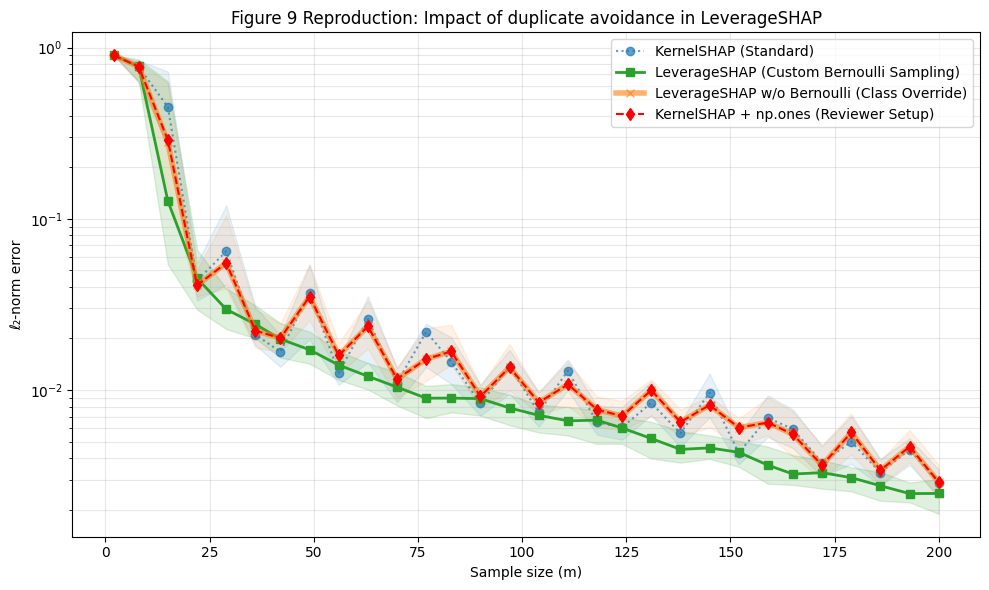

In [ ]:
# ── Plotting the Results ──────────────────────────────────────────────
plt.figure(figsize=(10, 6))

# Baseline: Standard KernelSHAP
plt.semilogy(
    budgets,
    np.median(errs_ks_standard, axis=0),
    "o:",
    label="KernelSHAP (Standard)",
    color="#1f77b4",
    alpha=0.7,
)

# The Custom Implementation
plt.semilogy(
    budgets,
    np.median(errs_lev_custom, axis=0),
    "s-",
    label="LeverageSHAP (Custom Bernoulli Sampling)",
    color="#2ca02c",
    linewidth=2,
)

# Concept A: The Class Override
plt.semilogy(
    budgets,
    np.median(errs_lev_wo_bern, axis=0),
    "x-",
    label="LeverageSHAP w/o Bernoulli (Class Override)",
    color="#ff7f0e",
    linewidth=4,
    alpha=0.6,
)

# Concept B: The Direct Reviewer Suggestion
# Drawn as a thin dashed line so it perfectly overlays the thick orange line above it
plt.semilogy(
    budgets,
    np.median(errs_ks_uniform, axis=0),
    "d--",
    label="KernelSHAP + np.ones (Reviewer Setup)",
    color="red",
    linewidth=1.5,
)

# Confidence intervals (omitting the 4th line to prevent visual clutter, as it's identical to the 3rd)
plt.fill_between(
    budgets,
    np.percentile(errs_ks_standard, 25, axis=0),
    np.percentile(errs_ks_standard, 75, axis=0),
    alpha=0.1,
    color="#1f77b4",
)
plt.fill_between(
    budgets,
    np.percentile(errs_lev_wo_bern, 25, axis=0),
    np.percentile(errs_lev_wo_bern, 75, axis=0),
    alpha=0.1,
    color="#ff7f0e",
)
plt.fill_between(
    budgets,
    np.percentile(errs_lev_custom, 25, axis=0),
    np.percentile(errs_lev_custom, 75, axis=0),
    alpha=0.15,
    color="#2ca02c",
)

plt.xlabel("Sample size (m)")
plt.ylabel("ℓ₂-norm error")
plt.title("Figure 9 Reproduction: Impact of duplicate avoidance in LeverageSHAP")
plt.legend()
plt.grid(visible=True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# ── Tabular Results ───────────────────────────────────────────────────
import pandas as pd

# Calculate the medians across all runs
median_ks_standard = np.median(errs_ks_standard, axis=0)
median_lev_custom = np.median(errs_lev_custom, axis=0)
median_lev_wo_bern = np.median(errs_lev_wo_bern, axis=0)
median_ks_uniform = np.median(errs_ks_uniform, axis=0)

# Create a clean DataFrame for a clear overview
df_results = pd.DataFrame(
    {
        "Budget (m)": budgets,
        "KernelSHAP (Standard)": median_ks_standard,
        "LeverageSHAP w/o Bernoulli (Override)": median_lev_wo_bern,
        "KernelSHAP + np.ones (Reviewer Setup)": median_ks_uniform,
        "LeverageSHAP (Custom Bernoulli)": median_lev_custom,
    }
).set_index("Budget (m)")

print("Median ℓ₂-norm error (Lower is better):")
print("-" * 100)
print(df_results.to_string(float_format=lambda x: f"{x:.5f}"))

print("\n" + "=" * 100)
print("DIRECT COMPARISON: Custom Bernoulli vs. Reviewer Setup (np.ones)")
print("=" * 100)

for i, b in enumerate(budgets):
    # Compare the custom implementation against the reviewer's baseline
    diff = median_ks_uniform[i] - median_lev_custom[i]
    rel_diff = (diff / median_ks_uniform[i]) * 100

    if diff > 0:
        print(f"m={b:<3}: Custom Sampling WINS! Error is {rel_diff:>4.1f}% lower.")
    else:
        print(f"m={b:<3}: Reviewer Setup WINS! Error is {abs(rel_diff):>4.1f}% lower.")

Median ℓ₂-norm error (Lower is better):
----------------------------------------------------------------------------------------------------
            KernelSHAP (Standard)  LeverageSHAP w/o Bernoulli (Override)  KernelSHAP + np.ones (Reviewer Setup)  LeverageSHAP (Custom Bernoulli)
Budget (m)                                                                                                                                      
2                         0.90230                                0.90230                                0.90230                          0.90230
8                         0.77130                                0.77382                                0.77382                          0.77667
15                        0.45012                                0.27952                                0.28783                          0.12703
22                        0.04356                                0.04092                                0.04092                       